# Visualizing opportunities with Matplotlib
This notebook uses the deterministic, synthetic SkillMatch seed dataset. Company names are illustrative; these are not real vacancies. Run all cells from top to bottom.


## 1. Load the same dataset

In [1]:
from pathlib import Path
import pandas as pd
root = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
jobs = pd.read_csv(root / 'data' / 'jobs.csv')
skills = pd.read_csv(root / 'data' / 'skills.csv')
jobs.head()
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'figure.dpi': 110})
purple = '#8764c5'
cyan = '#399a93'

## 2. Bar chart — most requested skills

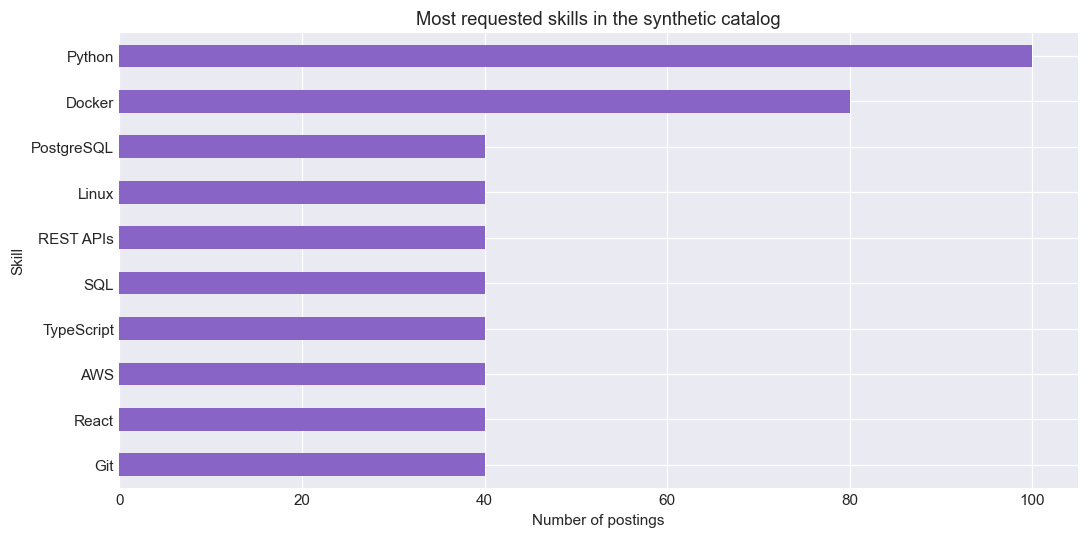

In [2]:
demand = jobs.assign(skill=jobs.skills.str.split('|')).explode('skill').skill.value_counts().head(10)
fig, ax = plt.subplots()
demand.sort_values().plot.barh(ax=ax, color=purple)
ax.set(title='Most requested skills in the synthetic catalog', xlabel='Number of postings', ylabel='Skill')
fig.tight_layout()
plt.show()

## 3. Scatter plot — salary bands

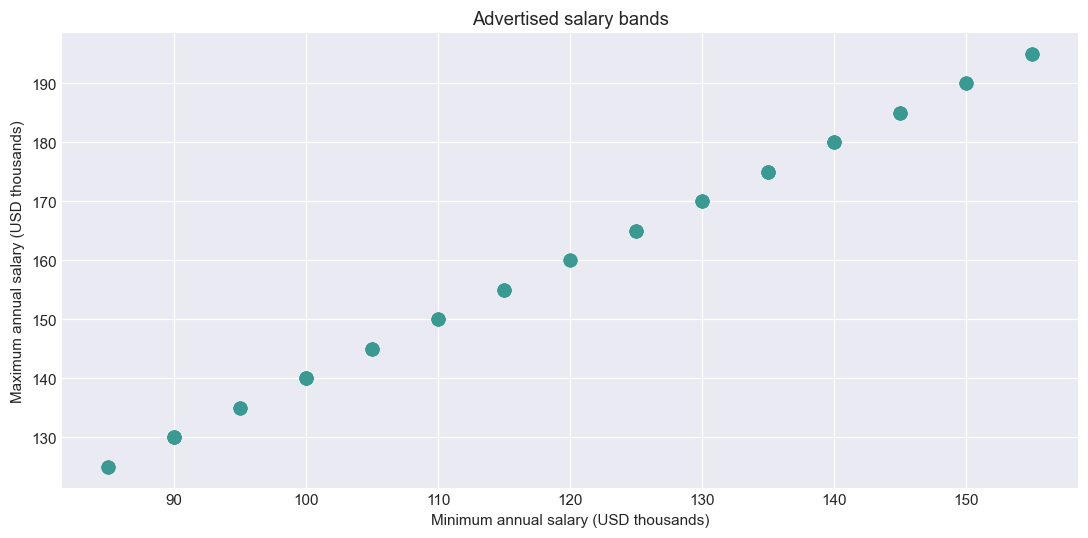

In [3]:
fig, ax = plt.subplots()
ax.scatter(jobs.salary_min / 1000, jobs.salary_max / 1000, color=cyan, alpha=0.4, s=65)
ax.set(title='Advertised salary bands', xlabel='Minimum annual salary (USD thousands)', ylabel='Maximum annual salary (USD thousands)')
fig.tight_layout()
plt.show()

## 4. Histogram — salary distribution

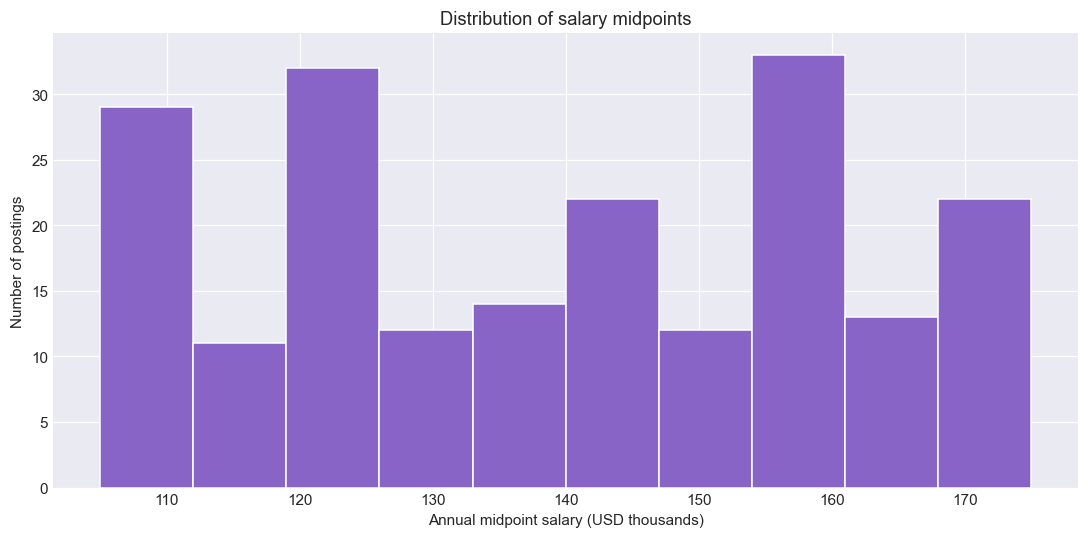

In [4]:
fig, ax = plt.subplots()
ax.hist((jobs.salary_min + jobs.salary_max) / 2000, bins=10, color=purple, edgecolor='white')
ax.set(title='Distribution of salary midpoints', xlabel='Annual midpoint salary (USD thousands)', ylabel='Number of postings')
fig.tight_layout()
plt.show()

## 5. Line chart — postings over time

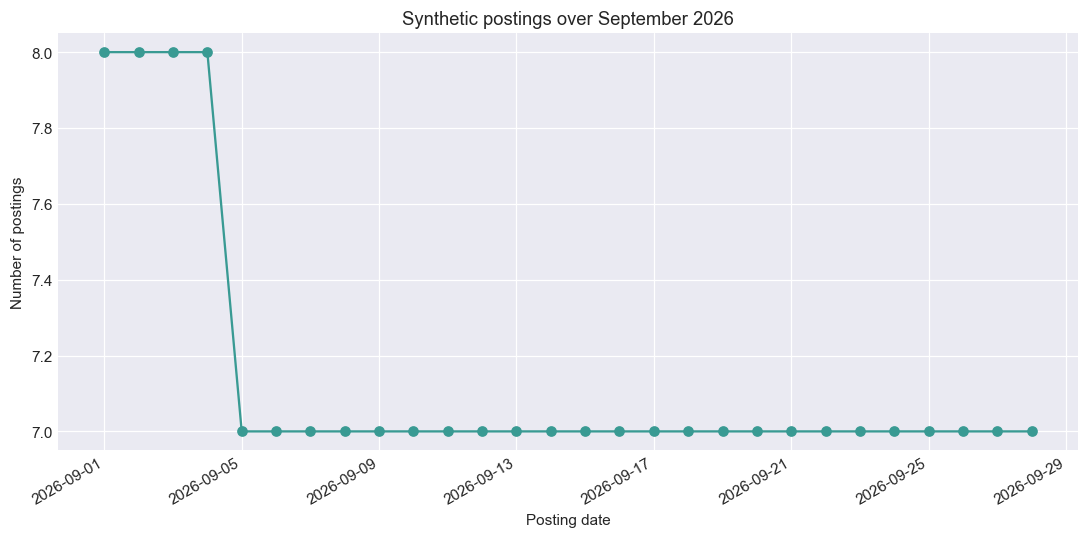

In [5]:
timeline = jobs.groupby(pd.to_datetime(jobs.posted_date)).size().sort_index()
fig, ax = plt.subplots()
ax.plot(timeline.index, timeline.values, color=cyan, marker='o')
ax.set(title='Synthetic postings over September 2026', xlabel='Posting date', ylabel='Number of postings')
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

## 6. Pie chart — employment types

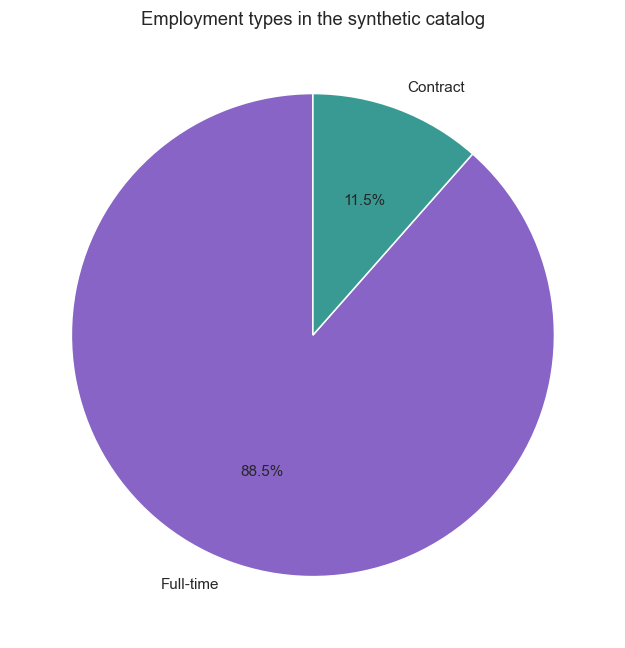

In [6]:
counts = jobs.employment_type.value_counts()
fig, ax = plt.subplots(figsize=(7, 6))
ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=[purple, cyan], startangle=90, wedgeprops={'edgecolor': 'white'})
ax.set_title('Employment types in the synthetic catalog')
fig.tight_layout()
plt.show()

## What the charts tell us
The seed deliberately balances roles and locations. Salary bands are generated with a fixed spread, so the scatter plot is linear by construction. Dates are simulated, not scraped. These plots demonstrate chart selection and labeling, not real market findings.

In [7]:
assert len(jobs) == 200
print('Five chart types generated from the shared seed dataset.')

Five chart types generated from the shared seed dataset.
